# Terrain Classification Notebook

In [ ]:
#@title Prep

!pip -q install pyngrok > /dev/null
!pip -q install streamlit > /dev/null
!pip -q install patool > /dev/null
!pip -q install keras==3.3.3 > /dev/null

import cv2
import gdown
import glob
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
import patoolib
import streamlit as st

from joblib import dump
import tqdm.notebook as tq
from pyngrok import ngrok

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from keras.applications.vgg16 import VGG16
from keras.models import Sequential
from keras.layers import Dense, Dropout, GlobalAveragePooling2D
from keras.optimizers import SGD

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires keras>=3.10.0, but you have keras 3.3.3 which is incompatible.
keras-hub 0.26.0 requires keras>=3.13, but you have keras 3.3.3 which is incompatible.


In [ ]:
import kagglehub
path = kagglehub.dataset_download('murtuza26/terrain-classification')

print('Data source import complete.')

100%|██████████| 580M/580M [00:06<00:00, 93.8MB/s]

Extracting files...


Data source import complete.


In [ ]:
import pandas as pd

In [ ]:
def df_maker(path):
    file_paths = []
    labels = []

    folds = os.listdir(path)
    for fold in folds:
        fold_path = os.path.join(os.path.join(path,fold), fold)
        file_list = os.listdir(fold_path)
        for file in file_list:
            file_path = os.path.join(fold_path,file)
            # Check if the file has a common image extension
            if file_path.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')):
                file_paths.append(file_path)
                labels.append(fold)

    file_series = pd.Series(file_paths,name="file_paths")
    label_series = pd.Series(labels,name="labels")

    df = pd.concat([file_series,label_series],axis=1)
    return df

In [ ]:
df = df_maker(path)

In [ ]:
df = df.sort_values(by="file_paths")

In [ ]:
df.iloc[1,0]

'/root/.cache/kagglehub/datasets/murtuza26/terrain-classification/versions/1/Desert Dataset/Desert Dataset/0--Thumbnail-Marketplace.png'

In [ ]:
np.unique(df['labels'], return_counts=True)

(array(['Desert Dataset', 'Forests Dataset', 'Lake Dataset',
        'Plains Dataset', 'Tundra Dataset', 'Urban Dataset',
        'Wetlands Dataset'], dtype=object),
 array([1306,  986,  277, 1278,  235,  226,  121]))

In [ ]:
train_df,test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["labels"])
train_df_split, val_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df["labels"]) # Splitting train_df into new training and validation sets

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
train_df_split = train_df_split.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

In [ ]:
def calculate_avg_rgb(df):
    avg_r_list = []
    avg_g_list = []
    avg_b_list = []

    for index, row in tq.tqdm(df.iterrows(), total=len(df), desc="Calculating Avg RGB"):
        img_path = row['file_paths']
        try:
            img = cv2.imread(img_path)
            if img is not None:
                # OpenCV reads images in BGR format by default
                avg_b, avg_g, avg_r = np.mean(img, axis=(0, 1))
                avg_r_list.append(avg_r)
                avg_g_list.append(avg_g)
                avg_b_list.append(avg_b)
            else:
                avg_r_list.append(np.nan)
                avg_g_list.append(np.nan)
                avg_b_list.append(np.nan)
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            avg_r_list.append(np.nan)
            avg_g_list.append(np.nan)
            avg_b_list.append(np.nan)

    df['avg_r'] = avg_r_list
    df['avg_g'] = avg_g_list
    df['avg_b'] = avg_b_list
    return df

print("Calculating average RGB for training data...")
train_df_split = calculate_avg_rgb(train_df_split)

print("Calculating average RGB for validation data...")
val_df = calculate_avg_rgb(val_df)

print("Calculating average RGB for test data...")
test_df = calculate_avg_rgb(test_df)

print("\nFirst 5 rows of train_df_split with new RGB features:")
display(train_df_split.head())
print("\nFirst 5 rows of val_df with new RGB features:")
display(val_df.head())
print("\nFirst 5 rows of test_df with new RGB features:")
display(test_df.head())

Calculating average RGB for training data...


Calculating Avg RGB: 100%|██████████| 2834/2834 [01:00<00:00, 46.55it/s] 


Calculating average RGB for validation data...


Calculating Avg RGB: 100%|██████████| 709/709 [00:14<00:00, 48.76it/s]


Calculating average RGB for test data...


...

,file_paths,labels,avg_r,avg_g,avg_b
0,/root/.cache/kagglehub/datasets/murtuza26/terr...,Forests Dataset,64.775842,88.103561,68.300500
1,/root/.cache/kagglehub/datasets/murtuza26/terr...,Desert Dataset,170.066681,157.134277,131.468262
2,/root/.cache/kagglehub/datasets/murtuza26/terr...,Plains Dataset,64.449997,75.372650,61.857849
3,/root/.cache/kagglehub/datasets/murtuza26/terr...,Plains Dataset,43.972015,56.942993,33.852493
4,/root/.cache/kagglehub/datasets/murtuza26/terr...,Lake Dataset,72.472118,62.892953,72.563505



First 5 rows of val_df with new RGB features:


,file_paths,labels,avg_r,avg_g,avg_b
0,/root/.cache/kagglehub/datasets/murtuza26/terr...,Plains Dataset,75.162140,85.942398,64.748108
1,/root/.cache/kagglehub/datasets/murtuza26/terr...,Plains Dataset,53.051056,59.459030,48.121490
2,/root/.cache/kagglehub/datasets/murtuza26/terr...,Desert Dataset,111.593002,98.541016,80.384048
3,/root/.cache/kagglehub/datasets/murtuza26/terr...,Desert Dataset,149.659302,129.726593,94.531982
4,/root/.cache/kagglehub/datasets/murtuza26/terr...,Tundra Dataset,185.922631,177.349909,157.966691



First 5 rows of test_df with new RGB features:


,file_paths,labels,avg_r,avg_g,avg_b
0,/root/.cache/kagglehub/datasets/murtuza26/terr...,Tundra Dataset,131.838844,129.215008,132.781985
1,/root/.cache/kagglehub/datasets/murtuza26/terr...,Desert Dataset,179.616272,164.013977,135.737152
2,/root/.cache/kagglehub/datasets/murtuza26/terr...,Plains Dataset,66.442908,81.460031,54.715350
3,/root/.cache/kagglehub/datasets/murtuza26/terr...,Desert Dataset,NaN,NaN,NaN
4,/root/.cache/kagglehub/datasets/murtuza26/terr...,Plains Dataset,74.162216,86.979141,61.588699


In [ ]:
train_valid = train_df_split.merge(pd.DataFrame({"file_paths":train_data.filepaths}), on='file_paths')

In [ ]:
test_valid = test_df.merge(pd.DataFrame({"file_paths":test_data.filepaths}), on='file_paths')

In [ ]:
np.save("train_rgb.npy", np.array(train_valid.iloc[:, -3:]))

In [ ]:
np.save("test_rgb.npy", np.array(test_valid.iloc[:, -3:]))

# **Convert to grayscale**

In [ ]:
def get_gray_flat_images(df):
  X_gray = []

  for i in range(len(df)):
    img = cv2.imread(df['file_paths'][i])
    X_gray.append(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))

  X_gray = np.array(X_gray)
  return np.reshape(X_gray, (X_gray.shape[0], 256*256))

In [ ]:
def get_original_images(df):
  X = []

  for i in range(len(df)):
    img = cv2.imread(df['file_paths'][i])
    X.append(img)

  return np.array(X)

# **Color Training**

In [ ]:
from keras.applications.vgg16 import VGG16
from keras.models import Sequential
from keras.layers import Dense, Dropout, GlobalAveragePooling2D
from keras.optimizers import SGD
from PIL import ImageFile
import tensorflow as tf

In [ ]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

color_vgg_expert = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(256, 256, 3)
)

cnn_model = Sequential()
cnn_model.add(color_vgg_expert)
cnn_model.add(GlobalAveragePooling2D())
cnn_model.add(Dense(1024, activation="relu"))
cnn_model.add(Dropout(0.3))
cnn_model.add(Dense(512, activation="relu"))
cnn_model.add(Dropout(0.3))
cnn_model.add(Dense(7, activation="softmax"))

cnn_model.compile(
    loss="categorical_crossentropy",
    optimizer=SGD(learning_rate=1e-4, momentum=0.95),
    metrics=["accuracy"]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history_color = cnn_model.fit(
    train_data,
    epochs=5,
    validation_data=val_data,
verbose=1
)

test_loss, test_acc = cnn_model.evaluate(test_data, verbose=0)
print(f"New color test accuracy: {test_acc:.4f}")

Epoch 1/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 76s 402ms/step - accuracy: 0.4281 - loss: 1.7464 - val_accuracy: 0.6899 - val_loss: 0.8566
Epoch 2/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 64s 368ms/step - accuracy: 0.7297 - loss: 0.7944 - val_accuracy: 0.8275 - val_loss: 0.5487
Epoch 3/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 64s 371ms/step - accuracy: 0.7084 - loss: 0.8775 - val_accuracy: 0.8536 - val_loss: 0.4410
Epoch 4/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 65s 372ms/step - accuracy: 0.8441 - loss: 0.4531 - val_accuracy: 0.8855 - val_loss: 0.3147
Epoch 5/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 67s 390ms/step - accuracy: 0.8801 - loss: 0.3418 - val_accuracy: 0.9000 - val_loss: 0.3084
New color test accuracy: 0.8868


In [ ]:
!gdown 1qCwMSULTHvsVKiQT-suKC6_C1qdqrZ7E

Downloading...
From (original): https://drive.google.com/uc?id=1qCwMSULTHvsVKiQT-suKC6_C1qdqrZ7E
From (redirected): https://drive.google.com/uc?id=1qCwMSULTHvsVKiQT-suKC6_C1qdqrZ7E&confirm=t&uuid=104e6fa9-da66-40c1-80e4-6fdf1e5b4acb
To: /content/color_model.keras
100% 126M/126M [00:00<00:00, 169MB/s]


In [ ]:
cnn_model.save("color_model.keras")
cnn_model = tf.keras.models.load_model("color_model.keras")

In [ ]:
predictions_output=cnn_model.predict(test_data)
predicted_class_indices = np.argmax(predictions_output, axis=1)

test_df_with_predictions = pd.DataFrame({"filepaths": test_data.filepaths,
                                         "true_label": test_data.classes,
                                         "predicted_label": predicted_class_indices
                                         })
output_filename = 'color_cnnv1.2.csv'

test_df_with_predictions.to_csv(output_filename, index=False)

print(f"Predictions saved to {output_filename}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 2/53 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 161ms/step
Predictions saved to color_cnnv1.2.csv


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(test_df_with_predictions["true_label"], test_df_with_predictions["predicted_label"])

0.9268867924528302

In [ ]:
from keras.models import Model
from keras.layers import Input

# Define a new input tensor with the expected shape of the images
feature_extractor_input = Input(shape=(256, 256, 3))

# Pass the new input through the VGG16 base model
# Note: layers[0] is the color_vgg_expert (VGG16 model)
x = cnn_model.layers[0](feature_extractor_input)

# Pass the output of VGG16 through the GlobalAveragePooling2D layer
outputs = cnn_model.layers[1](x)

# Create the feature extraction model
feature_extractor_model = Model(inputs=feature_extractor_input, outputs=outputs)

# Extract embeddings for training images
print("Extracting embeddings for training images...")
train_embeddings = feature_extractor_model.predict(train_data)

# Extract embeddings for testing images
print("Extracting embeddings for testing images...")
test_embeddings = feature_extractor_model.predict(test_data)

print("Embeddings extracted successfully!")
print(f"Shape of training embeddings: {train_embeddings.shape}")
print(f"Shape of testing embeddings: {test_embeddings.shape}")

Extracting embeddings for training images...
  6/171 ━━━━━━━━━━━━━━━━━━━━ 52s 319ms/step 

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


171/171 ━━━━━━━━━━━━━━━━━━━━ 42s 243ms/step
Extracting embeddings for testing images...
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step
Embeddings extracted successfully!
Shape of training embeddings: (2733, 512)
Shape of testing embeddings: (848, 512)


Train a Classifier on Embeddings

In [ ]:
X_train_emb = train_embeddings
y_train_emb = train_data.classes

X_test_emb = test_embeddings
y_test_emb = test_data.classes

# Initialize and train a RandomForestClassifier
print("Training RandomForestClassifier on embeddings...")
embedding_rf_model = RandomForestClassifier(random_state=42)
embedding_rf_model.fit(X_train_emb, y_train_emb)

print("Training complete.")

# Eval
print("Evaluating model...")
embedding_test_predictions = embedding_rf_model.predict(X_test_emb)
embedding_test_accuracy = accuracy_score(y_test_emb, embedding_test_predictions)

print(f"Accuracy on test embeddings: {embedding_test_accuracy:.4f}")

Training RandomForestClassifier on embeddings...
Training complete.
Evaluating model...
Accuracy on test embeddings: 0.9363



Classification report on test embeddings:
                  precision    recall  f1-score   support

  Desert Dataset       0.93      0.94      0.94       239
 Forests Dataset       0.92      0.93      0.93       194
    Lake Dataset       0.86      0.89      0.88        56
  Plains Dataset       0.99      0.99      0.99       256
  Tundra Dataset       0.80      0.79      0.80        42
   Urban Dataset       0.92      0.89      0.90        37
Wetlands Dataset       1.00      0.75      0.86        24

        accuracy                           0.94       848
       macro avg       0.92      0.88      0.90       848
    weighted avg       0.94      0.94      0.94       848



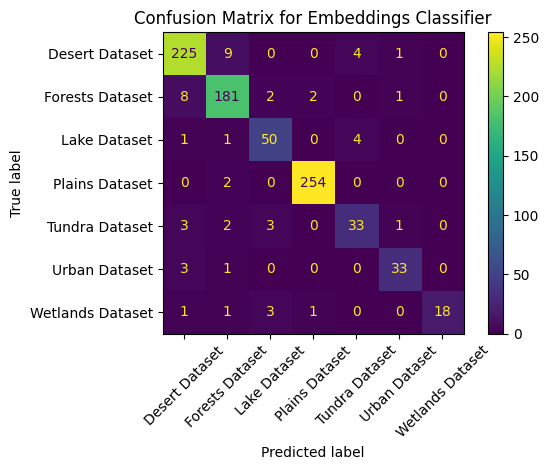

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\nClassification report on test embeddings:")
print(classification_report(y_test_emb, embedding_test_predictions, target_names=train_data.class_indices.keys()))

# confusion matrix
labels = list(train_data.class_indices.keys())
cm = confusion_matrix(y_test_emb, embedding_test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix for Embeddings Classifier")
plt.tight_layout()
plt.show()

# **Average-RGB logistic regression**




Average-RGB Logistic Regression validation accuracy: 0.6744
Average-RGB Logistic Regression test accuracy: 0.6557

Classification report on test set:
                  precision    recall  f1-score   support

  Desert Dataset       0.90      0.68      0.77       243
 Forests Dataset       0.70      0.72      0.71       194
    Lake Dataset       0.46      0.46      0.46        56
  Plains Dataset       0.79      0.78      0.79       256
  Tundra Dataset       0.24      0.34      0.28        44
   Urban Dataset       0.17      0.24      0.20        37
Wetlands Dataset       0.11      0.21      0.14        24

        accuracy                           0.66       854
       macro avg       0.48      0.49      0.48       854
    weighted avg       0.70      0.66      0.67       854



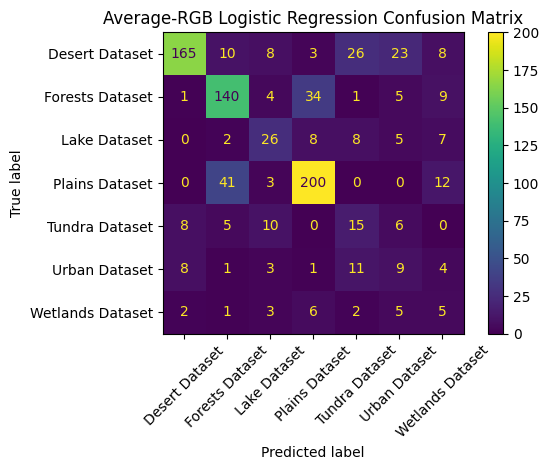

In [ ]:
from tqdm import tqdm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


X_train_rgb = train_df_split.dropna()[["avg_r", "avg_g", "avg_b"]]
y_train_rgb = train_df_split.dropna()["labels"]

X_val_rgb = val_df.dropna()[["avg_r", "avg_g", "avg_b"]]
y_val_rgb = val_df.dropna()["labels"]

X_test_rgb = test_df.dropna()[["avg_r", "avg_g", "avg_b"]]
y_test_rgb = test_df.dropna()["labels"]

rgb_log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42))
])

rgb_log_reg.fit(X_train_rgb, y_train_rgb)

val_pred_rgb = rgb_log_reg.predict(X_val_rgb)
test_pred_rgb = rgb_log_reg.predict(X_test_rgb)

val_acc_rgb = accuracy_score(y_val_rgb, val_pred_rgb)
test_acc_rgb = accuracy_score(y_test_rgb, test_pred_rgb)

print(f"Average-RGB Logistic Regression validation accuracy: {val_acc_rgb:.4f}")
print(f"Average-RGB Logistic Regression test accuracy: {test_acc_rgb:.4f}")
print("\nClassification report on test set:")
print(classification_report(y_test_rgb, test_pred_rgb))

labels = sorted(test_df["labels"].unique())
cm = confusion_matrix(y_test_rgb, test_pred_rgb, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45)
plt.title("Average-RGB Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

X_train shape: (6006, 256, 256, 3)
y shape: (6006,)
Terrain Classification: Forests Dataset


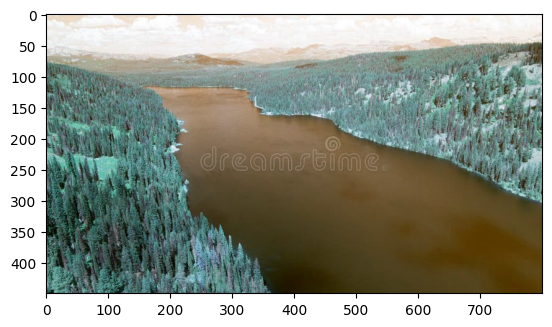

In [ ]:
print("X_train shape: (6006, 256, 256, 3)")
print("y shape: (6006,)")
img = cv2.imread(train_df_split['file_paths'][0])
plt.imshow(img)
print("Terrain Classification:", train_df_split['labels'][0])

In [ ]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, train_df_split['labels'])

RandomForestClassifier()

In [ ]:
rf_model.score(X_val, val_df['labels'])

1.0

In [ ]:
rf_model.score(X_test, test_df['labels'])

0.9948717948717949

In [ ]:
import tensorflow as tf

In [ ]:
def grayscale(image):
    # Convert the image to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    # Stack the single grayscale channel to create a 3-channel image (R=G=B=grayscale)
    return np.stack([gray_image, gray_image, gray_image], axis=-1)

 **Generators:**


In [ ]:
batch_size = 16
target_size = (256,256)

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True # Allow loading of truncated images

def is_valid_image(image_path):
    try:
        with Image.open(image_path) as img:
            img.verify() # Verify integrity of the image file
        return True
    except (IOError, OSError, Image.UnidentifiedImageError) as e:
        return False

train_df_filtered_cv2 = train_df_split.dropna(subset=['avg_r'])
val_df_filtered_cv2 = val_df.dropna(subset=['avg_r'])
test_df_filtered_cv2 = test_df.dropna(subset=['avg_r'])

# Further filter based on PIL's ability to open the image
train_df_final = train_df_filtered_cv2[train_df_filtered_cv2['file_paths'].apply(is_valid_image)]
val_df_final = val_df_filtered_cv2[val_df_filtered_cv2['file_paths'].apply(is_valid_image)]
test_df_final = test_df_filtered_cv2[test_df_filtered_cv2['file_paths'].apply(is_valid_image)]

train_data= tf.keras.preprocessing.image.ImageDataGenerator(
   preprocessing_function = grayscale
)
train_data=train_data.flow_from_dataframe(
    train_df_final,
    x_col="file_paths",
    y_col="labels",
    target_size=(target_size[0], target_size[1]),
    batch_size=batch_size,
    shuffle=False
)
val_data= tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function = grayscale
)
val_data= val_data.flow_from_dataframe(
    val_df_final,
    x_col="file_paths",
    y_col="labels",
    target_size=(target_size[0], target_size[1]),
    batch_size=batch_size,
    shuffle=False
)
test_data= tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function = grayscale
)
test_data= test_data.flow_from_dataframe(
    test_df_final,
    x_col="file_paths",
    y_col="labels",
    target_size=(target_size[0], target_size[1]),
    batch_size=batch_size,
    shuffle=False
)

Found 2733 validated image filenames belonging to 7 classes.
Found 690 validated image filenames belonging to 7 classes.
Found 848 validated image filenames belonging to 7 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 18 invalid image filename(s) in x_col="file_paths". These filename(s) will be ignored.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 4 invalid image filename(s) in x_col="file_paths". These filename(s) will be ignored.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 6 invalid image filename(s) in x_col="file_paths". These filename(s) will be ignored.
  warnings.warn(


In [ ]:
# load the expert VGG16 network but do not include the final layers
vgg_expert = VGG16(weights = 'imagenet', include_top = False, input_shape = (256, 256, 3))

# we add the first 12 layers of VGG16 to our own model vgg_model
vgg_model = Sequential()
vgg_model.add(vgg_expert)

# and then add our own layers on top of it
vgg_model.add(GlobalAveragePooling2D())
vgg_model.add(Dense(1024, activation = 'relu'))
vgg_model.add(Dropout(0.3))
vgg_model.add(Dense(512, activation = 'relu'))
vgg_model.add(Dropout(0.3))
vgg_model.add(Dense(7, activation = 'softmax'))

vgg_model.compile(loss = 'categorical_crossentropy',
          optimizer = SGD(learning_rate=1e-4, momentum=0.95),
          metrics=['accuracy'])

In [ ]:
vgg_model.fit(train_data,
              batch_size=batch_size,
              epochs=5,
              verbose=1,
              validation_data=val_data)

print("Accuracy: {}".format(vgg_model.evaluate(test_data, verbose=0)))

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


171/171 ━━━━━━━━━━━━━━━━━━━━ 151s 652ms/step - accuracy: 0.5153 - loss: 1.4857 - val_accuracy: 0.8391 - val_loss: 0.6679
Epoch 2/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 68s 392ms/step - accuracy: 0.7926 - loss: 0.6147 - val_accuracy: 0.8681 - val_loss: 0.3962
Epoch 3/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 82s 388ms/step - accuracy: 0.8643 - loss: 0.4014 - val_accuracy: 0.8652 - val_loss: 0.4385
Epoch 4/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 64s 373ms/step - accuracy: 0.8732 - loss: 0.3983 - val_accuracy: 0.9116 - val_loss: 0.2970
Epoch 5/5
171/171 ━━━━━━━━━━━━━━━━━━━━ 63s 364ms/step - accuracy: 0.8998 - loss: 0.2940 - val_accuracy: 0.8957 - val_loss: 0.2789
Accuracy: [0.31908223032951355, 0.8903301954269409]


In [ ]:
!gdown 1hzhYmWqcgfeefwwX-A5T2XGqs19lzaSe

Downloading...
From (original): https://drive.google.com/uc?id=1hzhYmWqcgfeefwwX-A5T2XGqs19lzaSe
From (redirected): https://drive.google.com/uc?id=1hzhYmWqcgfeefwwX-A5T2XGqs19lzaSe&confirm=t&uuid=9d591cae-a7a5-49a6-be8a-881bfdcb811f
To: /content/grayscale_model.keras
100% 126M/126M [00:00<00:00, 175MB/s]


In [ ]:
vgg_model = tf.keras.models.load_model("grayscale_model.keras")

In [ ]:
predictions_output=vgg_model.predict(test_data)
predicted_class_indices = np.argmax(predictions_output, axis=1)

test_df_with_predictions = pd.DataFrame({"filepaths": test_data.filepaths,
                                         "true_label": test_data.classes,
                                         "predicted_label": predicted_class_indices
                                         })
output_filename = 'grayscale_cnnv1.2.csv'

test_df_with_predictions.to_csv(output_filename, index=False)

print(f"Predictions saved to {output_filename}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 2/53 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step
Predictions saved to grayscale_cnnv1.2.csv


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(test_df_with_predictions["true_label"], test_df_with_predictions ["predicted_label"])

0.8974056603773585

In [ ]:
vgg_model.save("vgg_model.keras")

### Save the VGG16 model's predictions on the test set

In [ ]:
vgg_predictions_proba = vgg_model.predict(test_data)
vgg_predictions = vgg_predictions_proba.argmax(axis = 1)

predictions_df = pd.DataFrame({
    #'file_paths': test_df_final['file_paths'].values,
    'actual_labels': test_data.classes,
    'predicted_labels': vgg_predictions
})

display(predictions_df.head())

 4/53 ━━━━━━━━━━━━━━━━━━━━ 12s 252ms/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step


,actual_labels,predicted_labels
0,4,2
1,0,0
2,3,3
3,3,0
4,3,2


In [ ]:
predictions_df.to_csv("grayscale predictions.csv")

In [ ]:
import numpy as np

np.save("train_gray.npy", train_embeddings)
np.save("test_gray.npy", test_embeddings)

In [ ]:
from keras.models import Model
from keras.layers import Input

# Define a new input tensor with the expected shape of the images
feature_extractor_input = Input(shape=(256, 256, 3))

# Pass the new input through the VGG16 base model (vgg_model.layers[0])
# Note: layers[0] is the color_vgg_expert (VGG16 model)
x = vgg_model.layers[0](feature_extractor_input)

# Pass the output of VGG16 through the GlobalAveragePooling2D layer (vgg_model.layers[1])
outputs = vgg_model.layers[1](x)

# Create the feature extraction model
feature_extractor_model = Model(inputs=feature_extractor_input, outputs=outputs)

# Extract embeddings for training images
print("Extracting embeddings for training images...")
train_embeddings = feature_extractor_model.predict(train_data)

# Extract embeddings for testing images
print("Extracting embeddings for testing images...")
test_embeddings = feature_extractor_model.predict(test_data)

print("Embeddings extracted successfully!")
print(f"Shape of training embeddings: {train_embeddings.shape}")
print(f"Shape of testing embeddings: {test_embeddings.shape}")

Extracting embeddings for training images...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


  6/171 ━━━━━━━━━━━━━━━━━━━━ 49s 300ms/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


171/171 ━━━━━━━━━━━━━━━━━━━━ 30s 170ms/step
Extracting embeddings for testing images...
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 175ms/step
Embeddings extracted successfully!
Shape of training embeddings: (2733, 512)
Shape of testing embeddings: (848, 512)


In [ ]:
# Prepare data for the classifier
X_train_emb = train_embeddings
y_train_emb = train_data.classes # Labels corresponding to training images

X_test_emb = test_embeddings
y_test_emb = test_data.classes   # Labels corresponding to testing images

In [ ]:
import numpy as np

# Load the RGB data
train_rgb = np.load("train_rgb.npy")
test_rgb = np.load("test_rgb.npy")

# Append the RGB data to the embeddings
X_train_emb = np.concatenate((X_train_emb, train_rgb), axis=1)
X_test_emb = np.concatenate((X_test_emb, test_rgb), axis=1)

print(f"New shape of X_train_emb: {X_train_emb.shape}")
print(f"New shape of X_test_emb: {X_test_emb.shape}")

New shape of X_train_emb: (2733, 515)
New shape of X_test_emb: (848, 515)


In [ ]:
# Initialize and train a RandomForestClassifier
print("Training RandomForestClassifier on embeddings...")
embedding_rf_model = RandomForestClassifier(random_state=42)
embedding_rf_model.fit(X_train_emb, y_train_emb)

print("Training complete.")

# Eval
print("Evaluating model...")
embedding_test_predictions = embedding_rf_model.predict(X_test_emb)
embedding_test_accuracy = accuracy_score(y_test_emb, embedding_test_predictions)

print(f"Accuracy on test embeddings: {embedding_test_accuracy:.4f}")

Training RandomForestClassifier on embeddings...
Training complete.
Evaluating model...
Accuracy on test embeddings: 0.9116



Classification report on test embeddings:
                  precision    recall  f1-score   support

  Desert Dataset       0.91      0.92      0.91       239
 Forests Dataset       0.91      0.94      0.92       194
    Lake Dataset       0.70      0.82      0.75        56
  Plains Dataset       0.98      0.98      0.98       256
  Tundra Dataset       0.72      0.55      0.62        42
   Urban Dataset       0.84      0.86      0.85        37
Wetlands Dataset       1.00      0.54      0.70        24

        accuracy                           0.90       848
       macro avg       0.86      0.80      0.82       848
    weighted avg       0.91      0.90      0.90       848



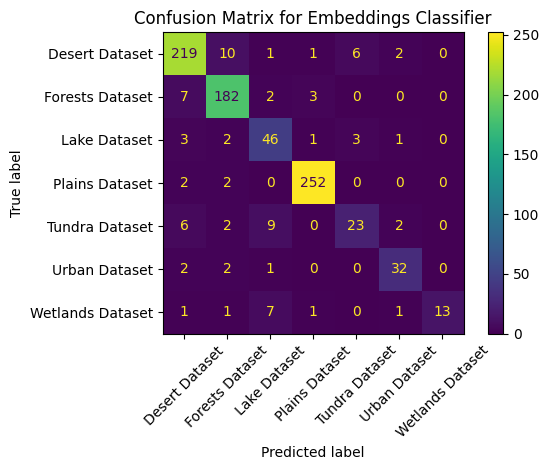

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\nClassification report on test embeddings:")
print(classification_report(y_test_emb, embedding_test_predictions, target_names=train_data.class_indices.keys()))

# confusion matrix
labels = list(train_data.class_indices.keys())
cm = confusion_matrix(y_test_emb, embedding_test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix for Embeddings Classifier")
plt.tight_layout()
plt.show()